In [193]:
# ── Global paths ──────────────────────────────────────────────────────────────
SWEAT_0 = "../20260404-experiment/sweat.csv"   # Defective — NH3 pin disconnected (miswired from start)
SWEAT_1 = "../20260405-experiment/sweat.csv"   # Reference — clean wiring
SWEAT_2 = "../20260331-experiment/sweat.csv"
BLOOD_0 = "../20260406-experiment/1.5_blood.csv"
BLOOD_1 = "../20260406-experiment/1.5_blood_2.csv"
BLOOD_VALIDATE_1 = "../20260331-experiment/1.5blood_1.csv"

MEMS = ["voc", "nh3", "hcho"]

# Smoothing params
ROLLING_WINDOW = 20   # samples (= seconds at 1 Hz)
SG_WINDOW      = 31   # Savitzky-Golay window (must be odd)
SG_POLY        = 3    # Savitzky-Golay polynomial order

# SWEAT_0 defect: NH3 zero runs (rows where NH3 = 0.0 V)
SWEAT_0_DEFECT_ZERO_RUNS = [(3912, 3983), (4012, 4036)]  # (start_row, end_row)


In [194]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

def load(path, t_min=0, t_max=None):
    df = pd.read_csv(path, parse_dates=["wall_time"])
    df["elapsed_s"] = (df["wall_time"] - df["wall_time"].iloc[0]).dt.total_seconds()
    for col in MEMS:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df = df[df["elapsed_s"] >= t_min]
    if t_max is not None:
        df = df[df["elapsed_s"] < t_max]
    return df.reset_index(drop=True)

SWEAT_1_RESET_S = 4000   # Reset event — recording restarted, sensor stayed powered

sweat_0  = load(SWEAT_0, t_max=4000)
sweat_1  = load(SWEAT_1)                                 # full — for initial visualization
sweat_1a = load(SWEAT_1, t_max=SWEAT_1_RESET_S)         # first sweat samples (2, 3) @ 3850s
sweat_1b = load(SWEAT_1, t_min=SWEAT_1_RESET_S)         # second sweat sample (1) @ 6350s
sweat_1b = sweat_1b.assign(                              # reset elapsed to 0 at reset point
    elapsed_s=sweat_1b["elapsed_s"] - sweat_1b["elapsed_s"].iloc[0]
)
sweat_2  = load(SWEAT_2)
blood_0  = load(BLOOD_0)
blood_1  = load(BLOOD_1, t_min=1750)                     # trim stabilization

print({
    "sweat_0":  len(sweat_0),
    "sweat_1":  len(sweat_1),
    "sweat_1a": len(sweat_1a),
    "sweat_1b": len(sweat_1b),
    "sweat_2":  len(sweat_2),
    "blood_0":  len(blood_0),
    "blood_1":  len(blood_1),
})


{'sweat_0': 3874, 'sweat_1': 6299, 'sweat_1a': 3909, 'sweat_1b': 2390, 'sweat_2': 5574, 'blood_0': 3666, 'blood_1': 1908}


## SWEAT_0 Defect Investigation

**Problem:** The NH3 sensor wire was miswired to the VOC ADC pin from the beginning of the session — not during recording.

**Effect on NH3:** Pin 34 (NH3) was floating/unconnected → reads `0.0 V` for large blocks of the session.

**Effect on VOC:** The NH3 wire loading pin 35 (VOC) might suppress the VOC readings.

**Conclusion:** SWEAT_0 VOC and NH3 channels are both unreliable and should not be used for model training.


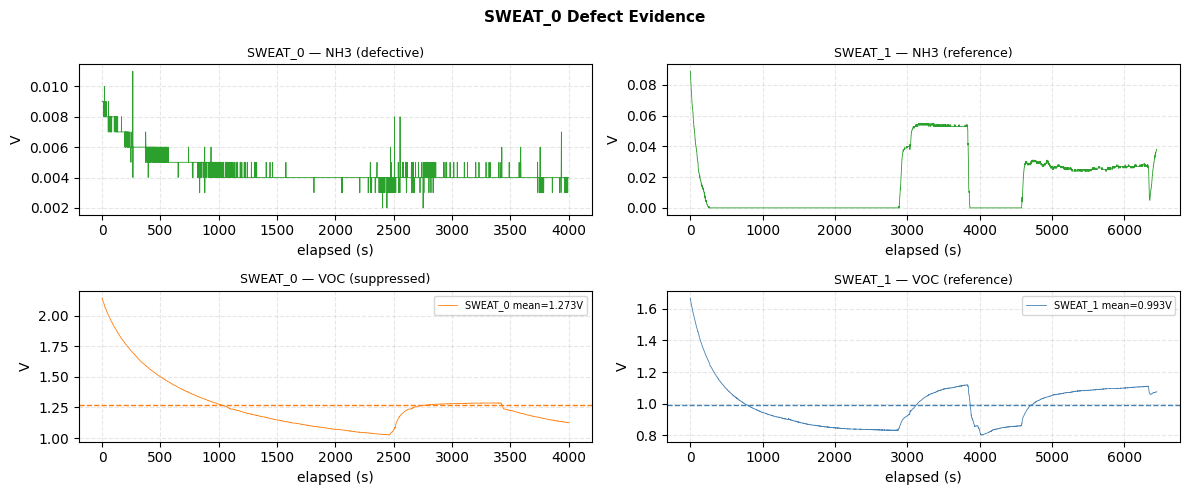

NH3 zeros in SWEAT_0: 0/3874 (0.0%)
VOC mean — SWEAT_0: 1.273 V   SWEAT_1: 0.993 V  (diff: -0.280 V)


In [195]:
fig, axes = plt.subplots(2, 2, figsize=(12, 5))
fig.suptitle("SWEAT_0 Defect Evidence", fontsize=11, fontweight="bold")

# Detect zero-run time spans directly from the trimmed dataframe
def zero_time_spans(df, col):
    is_zero = (df[col] == 0.0)
    spans = []
    in_run = False
    for i, val in enumerate(is_zero):
        if val and not in_run:
            in_run = True
            t_start = df["elapsed_s"].iloc[i]
        elif not val and in_run:
            in_run = False
            spans.append((t_start, df["elapsed_s"].iloc[i - 1]))
    if in_run:
        spans.append((t_start, df["elapsed_s"].iloc[-1]))
    return spans

# NH3: stuck-at-zero blocks (defective)
ax = axes[0, 0]
ax.plot(sweat_0["elapsed_s"], sweat_0["nh3"], color="tab:green", linewidth=0.6)
for t0, t1 in zero_time_spans(sweat_0, "nh3"):
    ax.axvspan(t0, t1, color="red", alpha=0.2, label="stuck at 0 V")
ax.set_title("SWEAT_0 — NH3 (defective)", fontsize=9)
ax.set_ylabel("V"); ax.set_xlabel("elapsed (s)")
ax.grid(True, alpha=0.3, linestyle="--")
handles, labels = ax.get_legend_handles_labels()
if handles:
    ax.legend(handles[:1], labels[:1], fontsize=7)

# NH3 reference (full signal)
ax = axes[0, 1]
ax.plot(sweat_1["elapsed_s"], sweat_1["nh3"], color="tab:green", linewidth=0.6)
ax.set_title("SWEAT_1 — NH3 (reference)", fontsize=9)
ax.set_ylabel("V"); ax.set_xlabel("elapsed (s)")
ax.grid(True, alpha=0.3, linestyle="--")

# VOC defective
ax = axes[1, 0]
ax.plot(sweat_0["elapsed_s"], sweat_0["voc"], color="tab:orange", linewidth=0.6, label=f"SWEAT_0 mean={sweat_0['voc'].mean():.3f}V")
ax.axhline(sweat_0["voc"].mean(), color="tab:orange", linestyle="--", linewidth=1)
ax.set_title("SWEAT_0 — VOC (suppressed)", fontsize=9)
ax.set_ylabel("V"); ax.set_xlabel("elapsed (s)")
ax.legend(fontsize=7); ax.grid(True, alpha=0.3, linestyle="--")

# VOC reference
ax = axes[1, 1]
ax.plot(sweat_1["elapsed_s"], sweat_1["voc"], color="steelblue", linewidth=0.6, label=f"SWEAT_1 mean={sweat_1['voc'].mean():.3f}V")
ax.axhline(sweat_1["voc"].mean(), color="steelblue", linestyle="--", linewidth=1)
ax.set_title("SWEAT_1 — VOC (reference)", fontsize=9)
ax.set_ylabel("V"); ax.set_xlabel("elapsed (s)")
ax.legend(fontsize=7); ax.grid(True, alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()

nh3_zeros = (sweat_0["nh3"] == 0.0).sum()
print(f"NH3 zeros in SWEAT_0: {nh3_zeros}/{len(sweat_0)} ({100*nh3_zeros/len(sweat_0):.1f}%)")
print(f"VOC mean — SWEAT_0: {sweat_0['voc'].mean():.3f} V   SWEAT_1: {sweat_1['voc'].mean():.3f} V  (diff: {sweat_1['voc'].mean()-sweat_0['voc'].mean():.3f} V)")


## Initial Visualization

Raw signal with rolling average and Savitzky-Golay smoothing overlaid.
SWEAT_0 is included for completeness but its VOC/NH3 channels are defective (see above).


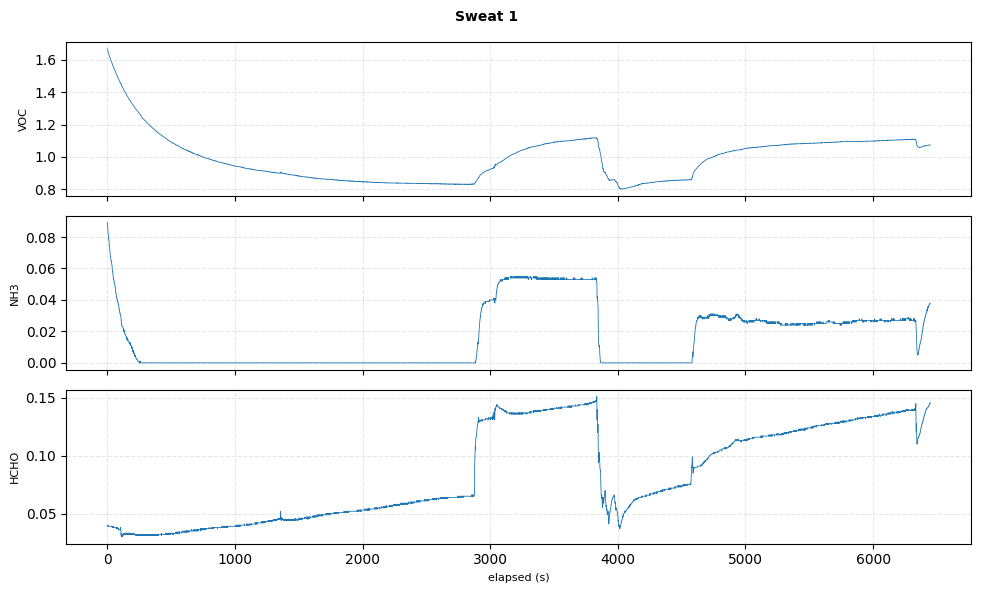

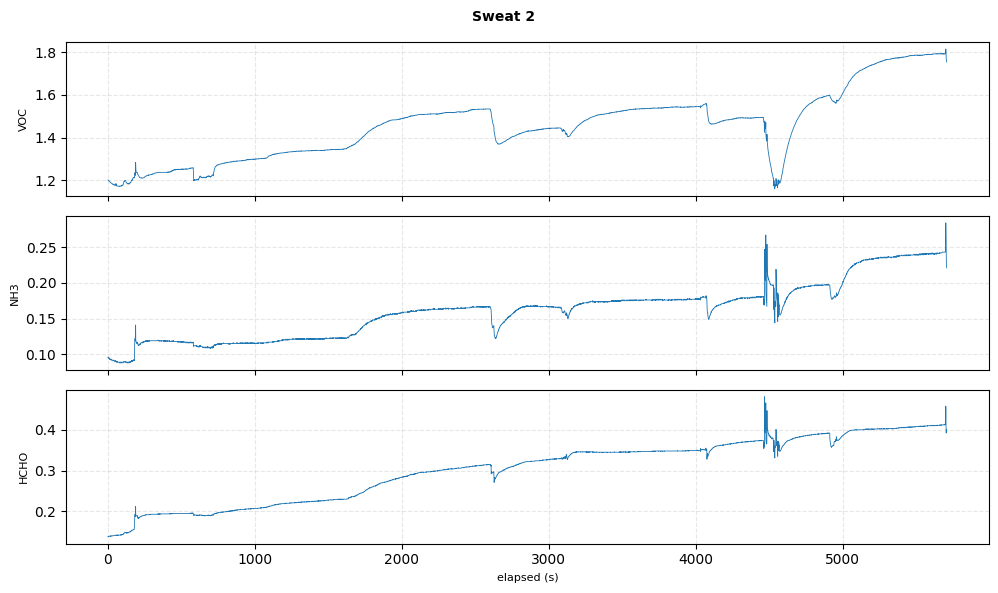

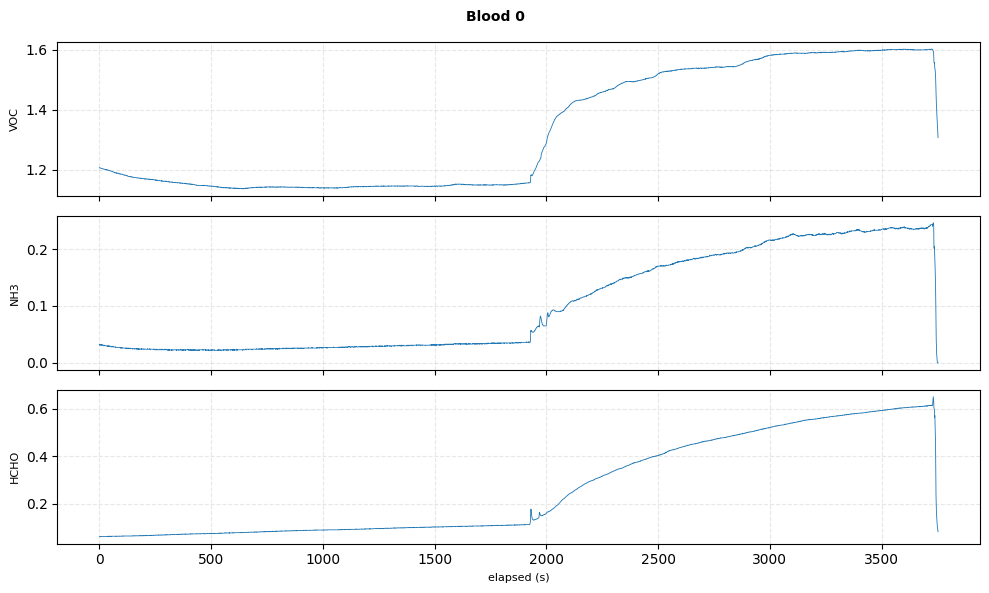

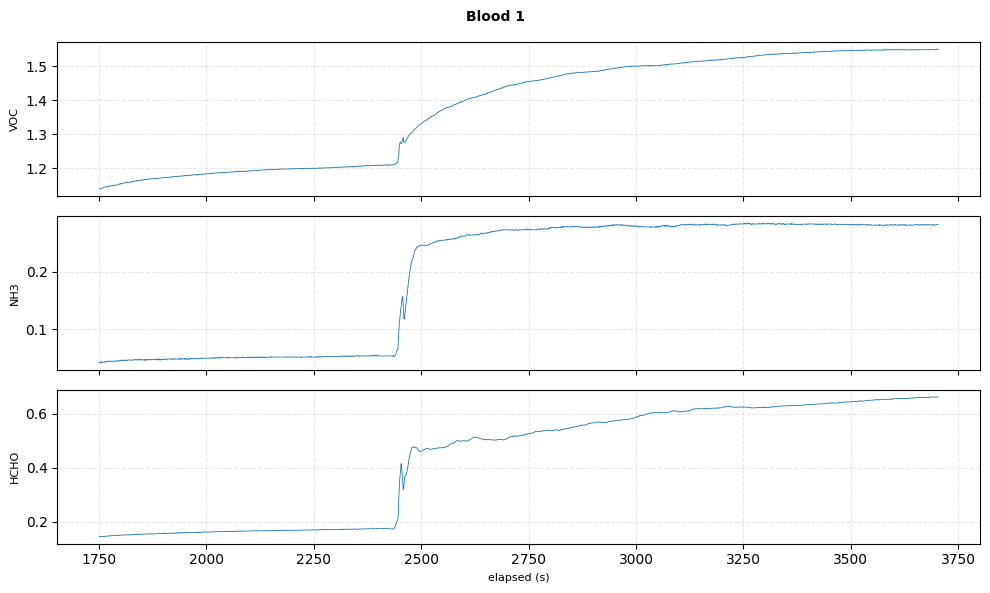

In [196]:
datasets = {
    "Sweat 1":  sweat_1,
    "Sweat 2":  sweat_2,
    "Blood 0":  blood_0,
    "Blood 1":  blood_1,
}

def plot_raw(name, df):
    fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
    fig.suptitle(name, fontsize=10, fontweight="bold")

    for ax, col in zip(axes, MEMS):
        ax.plot(df["elapsed_s"], df[col], linewidth=0.6)
        ax.set_ylabel(col.upper(), fontsize=8)
        ax.grid(True, alpha=0.3, linestyle="--")

    axes[-1].set_xlabel("elapsed (s)", fontsize=8)
    plt.tight_layout()
    plt.show()

for name, df in datasets.items():
    plot_raw(name, df)


## Filtered Visualization

Datasets in scope: **SWEAT_1a, SWEAT_1b, BLOOD_0, BLOOD_1**. SWEAT_0 and SWEAT_2 excluded for now.

All channels use a **causal EMA filter** (real-time compatible — no future data used).

| Dataset | Trimming | VOC | NH3 | HCHO |
|---------|----------|-----|-----|------|
| SWEAT_1a | 0s – 4000s (Reset) | EMA span=30, artifact patch 2950–3100s | EMA span=30, artifact patch 2950–3100s | EMA span=30, artifact patch 2950–3100s |
| SWEAT_1b | 4000s+ (reset to 0) | EMA span=30 | EMA span=80 (noisy) | EMA span=30, artifact patch 540–570s |
| BLOOD_0 | 0s+ | EMA span=30 | EMA span=30, interpolate isolated zeros, artifact patch 1970–2030s | EMA span=30 |
| BLOOD_1 | 1750s+ | EMA span=30 | EMA span=30 | EMA span=30 |

In [197]:
# ── Per-dataset filter config ─────────────────────────────────────────────────
# span: default EMA span (samples ≈ seconds at 1 Hz)
# span_override: {col: span} — per-channel span override
# interpolate_cols: columns where isolated zeros are interpolated before filtering
# artifact_windows: {col: [(t_start, t_end), ...]} — regions to patch via linear interp

FILTER_CONFIG = {
    "SWEAT_1a": {
        "span": 30,
        "span_override": {},
        "interpolate_cols": [],
        "artifact_windows": {
            "voc":  [(2950, 3100)],
            "nh3":  [(2950, 3100)],
            "hcho": [(2950, 3100)],
        },
    },
    "SWEAT_1b": {
        "span": 30,
        "span_override": {"nh3": 80},   # NH3 is noisy — smooth more aggressively
        "interpolate_cols": [],
        "artifact_windows": {
            "hcho": [(540, 570)],
        },
    },
    "BLOOD_0": {
        "span": 30,
        "span_override": {},
        "interpolate_cols": ["nh3"],
        "artifact_windows": {
            "nh3": [(1970, 2030)],
        },
    },
    "BLOOD_1": {
        "span": 30,
        "span_override": {},
        "interpolate_cols": [],
        "artifact_windows": {},
    },
}

# ── Filter application ────────────────────────────────────────────────────────
def apply_filter(df, config):
    out = df.copy()
    for col in MEMS:
        s = out[col].copy().astype(float)

        # Interpolate isolated zeros
        if col in config.get("interpolate_cols", []):
            s[s == 0.0] = float("nan")
            s = s.interpolate(method="linear").ffill().bfill()

        # Patch artifact windows via linear interpolation (Option C)
        for t0, t1 in config.get("artifact_windows", {}).get(col, []):
            mask = (out["elapsed_s"] >= t0) & (out["elapsed_s"] <= t1)
            s[mask] = float("nan")
            s = s.interpolate(method="linear").ffill().bfill()

        # Causal EMA — per-channel span override if specified
        span = config.get("span_override", {}).get(col, config["span"])
        out[col] = s.ewm(span=span, adjust=False).mean()

    return out

filtered = {
    name: apply_filter(df, FILTER_CONFIG[name])
    for name, df in [
        ("SWEAT_1a", sweat_1a),
        ("SWEAT_1b", sweat_1b),
        ("BLOOD_0",  blood_0),
        ("BLOOD_1",  blood_1),
    ]
}


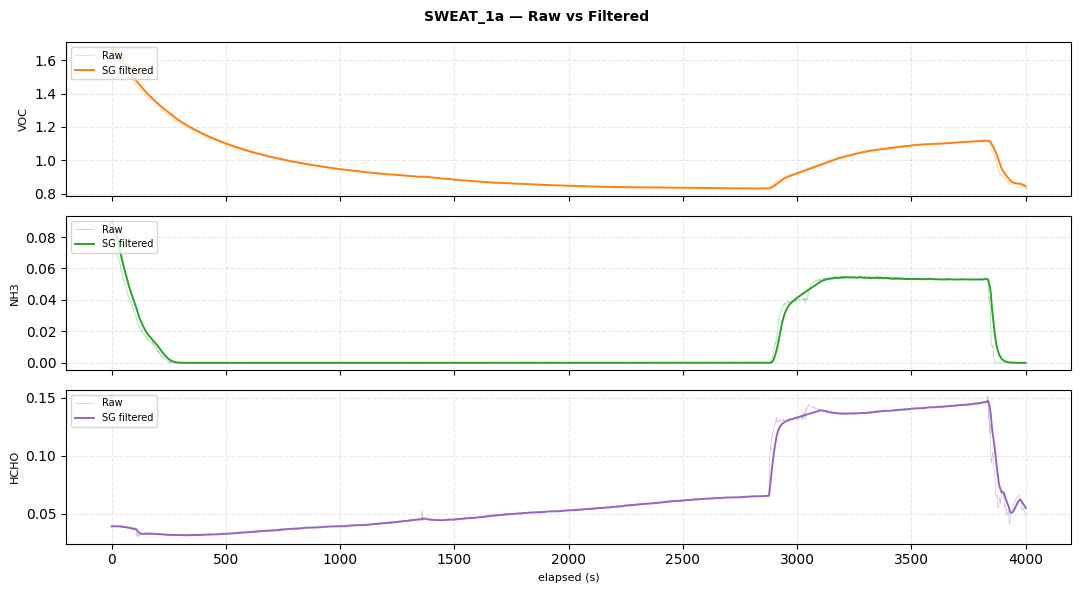

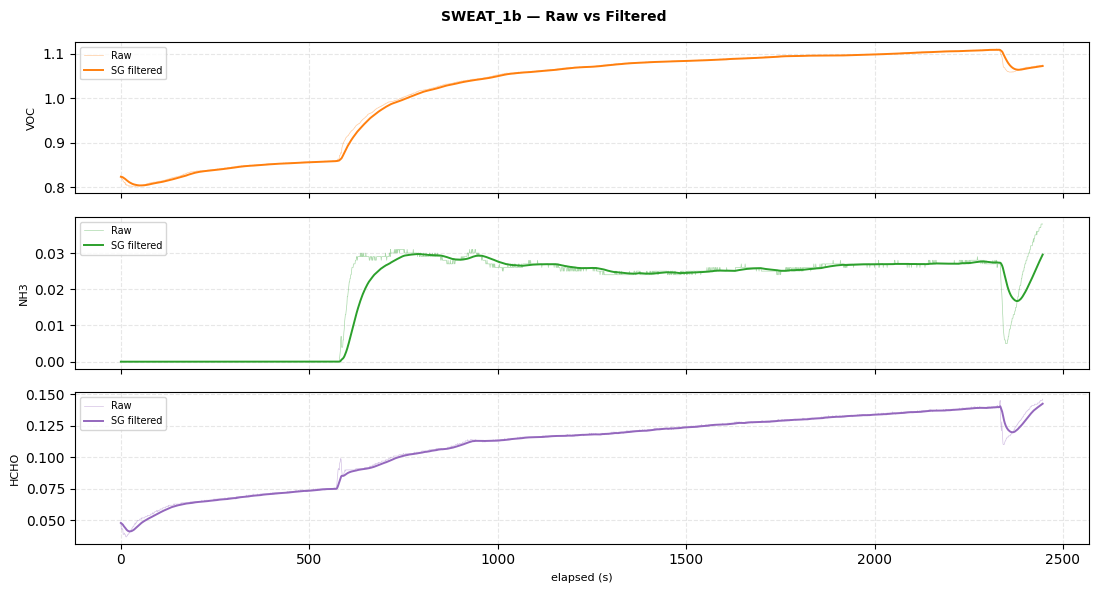

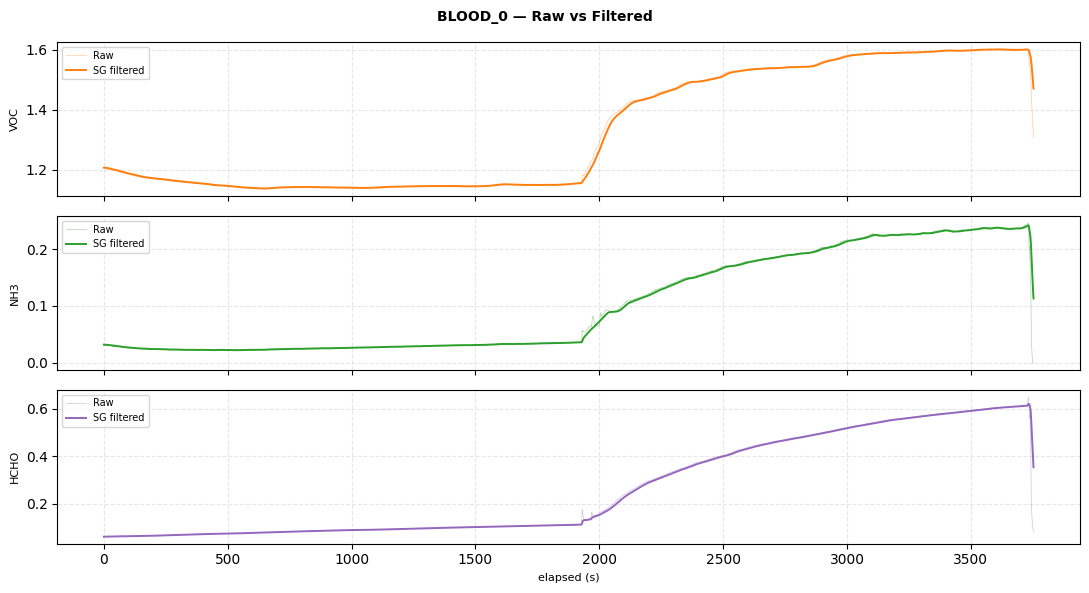

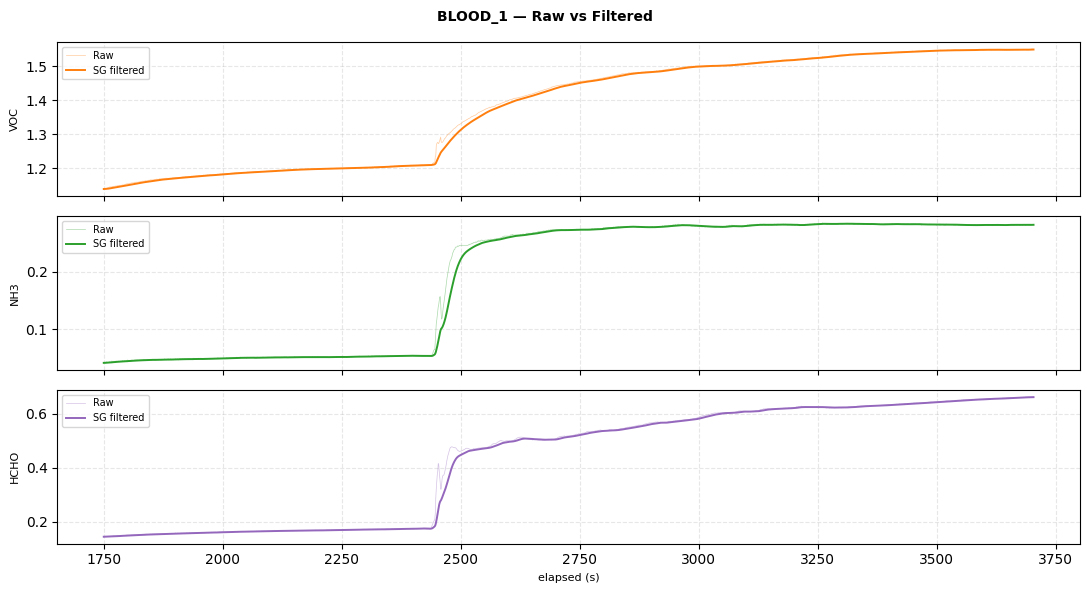

In [198]:
COLORS = {"voc": "tab:orange", "nh3": "tab:green", "hcho": "tab:purple"}

raw_map = {
    "SWEAT_1a": sweat_1a,
    "SWEAT_1b": sweat_1b,
    "BLOOD_0":  blood_0,
    "BLOOD_1":  blood_1,
}

for name, filt_df in filtered.items():
    raw_df = raw_map[name]
    fig, axes = plt.subplots(3, 1, figsize=(11, 6), sharex=True)
    fig.suptitle(f"{name} — Raw vs Filtered", fontsize=10, fontweight="bold")

    for ax, col in zip(axes, MEMS):
        color = COLORS[col]
        ax.plot(raw_df["elapsed_s"],  raw_df[col],  color=color, linewidth=0.5, alpha=0.4, label="Raw")
        ax.plot(filt_df["elapsed_s"], filt_df[col], color=color, linewidth=1.4, label="SG filtered")
        ax.set_ylabel(col.upper(), fontsize=8)
        ax.legend(fontsize=7, loc="upper left")
        ax.grid(True, alpha=0.3, linestyle="--")

    axes[-1].set_xlabel("elapsed (s)", fontsize=8)
    plt.tight_layout()
    plt.show()


## Baseline and Sensor Drift Correction

Fits a linear trend to the pre-sample window of each channel and subtracts it from the full signal. Corrects for both the session baseline offset and slow in-session drift.

```
corrected(t) = filtered(t) − (a·t + b),   clipped at 0
```



SWEAT_1a  (baseline window: 1500–2800s,  1271 rows)
  channel      slope (V/s)   intercept (V)
  voc            -0.000036          0.9241
  nh3            -0.000000          0.0000
  hcho            0.000016          0.0218

SWEAT_1b  (baseline window: 0–570s,  557 rows)
  channel      slope (V/s)   intercept (V)
  voc             0.000104          0.8080
  nh3             0.000000         -0.0000
  hcho            0.000052          0.0500

BLOOD_0  (baseline window: 0–1900s,  1856 rows)
  channel      slope (V/s)   intercept (V)
  voc            -0.000015          1.1653
  nh3             0.000006          0.0221
  hcho            0.000027          0.0620

BLOOD_1  (baseline window: 1750–2440s,  674 rows)
  channel      slope (V/s)   intercept (V)
  voc             0.000091          0.9945
  nh3             0.000014          0.0200
  hcho            0.000041          0.0783


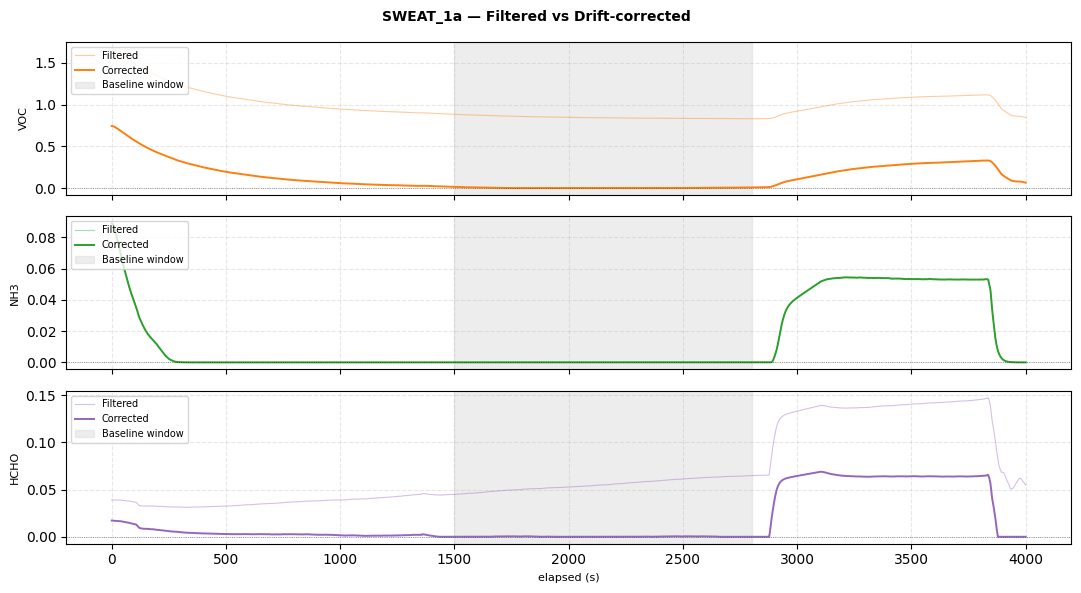

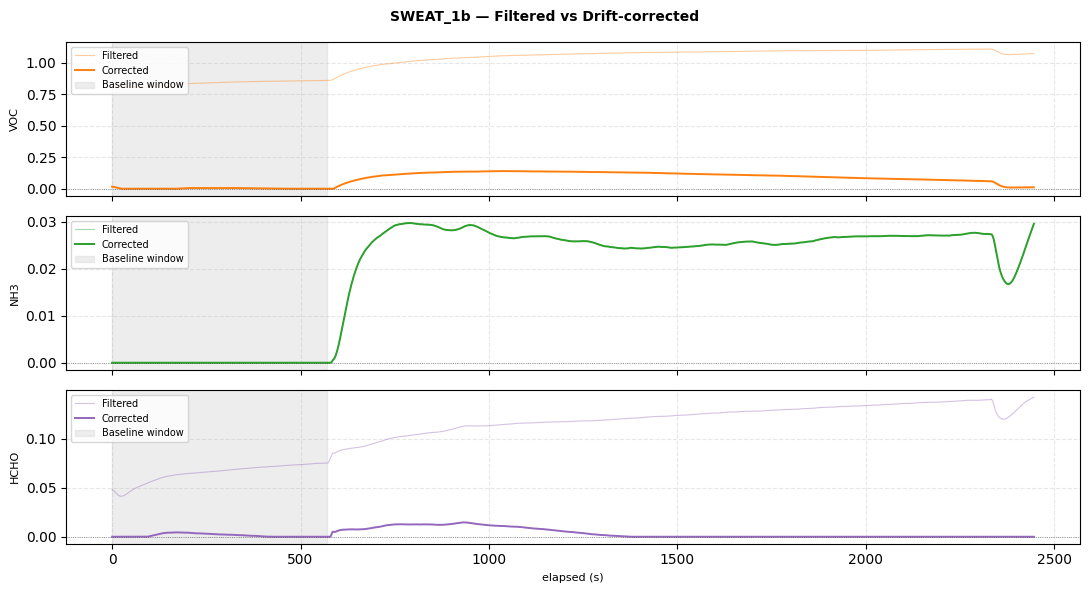

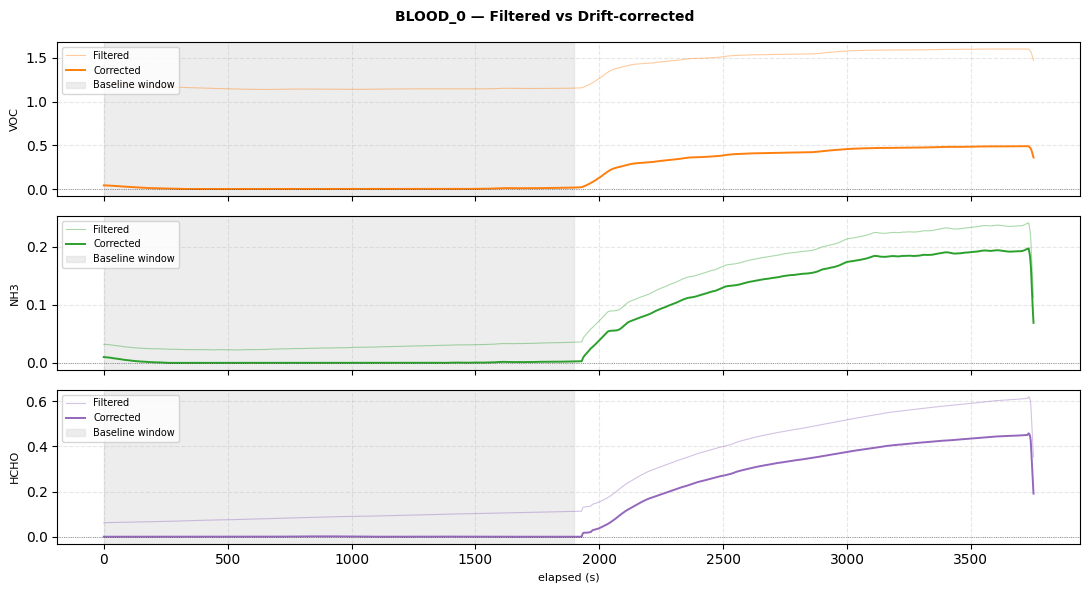

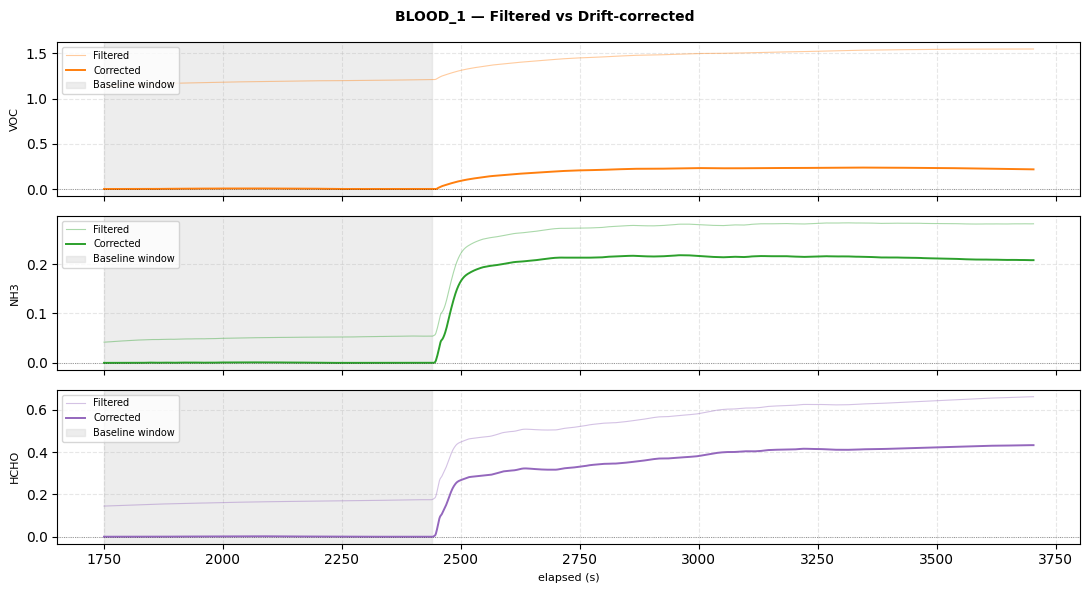

In [199]:
import numpy as np

# Pre-sample baseline windows (elapsed_s) per sub-dataset — rows before sample introduction
BASELINE_WINDOWS = {
    "SWEAT_1a": (1500, 2800),
    "SWEAT_1b": (0,    570),
    "BLOOD_0":  (0,    1900),
    "BLOOD_1":  (1750, 2440),
}

corrected = {}   # {name: DataFrame with drift-corrected MEMS channels}

for name, df in [
    ("SWEAT_1a", sweat_1a),
    ("SWEAT_1b", sweat_1b),
    ("BLOOD_0",  blood_0),
    ("BLOOD_1",  blood_1),
]:
    filt_df = filtered[name].copy()
    t0, t1  = BASELINE_WINDOWS[name]
    base_mask = (filt_df["elapsed_s"] >= t0) & (filt_df["elapsed_s"] <= t1)
    t_all = filt_df["elapsed_s"].values

    print(f"\n{name}  (baseline window: {t0}–{t1}s,  {base_mask.sum()} rows)")
    print(f"  {'channel':<8}  {'slope (V/s)':>14}  {'intercept (V)':>14}")

    for col in MEMS:
        t_base = filt_df.loc[base_mask, "elapsed_s"].values
        s_base = filt_df.loc[base_mask, col].values

        # Fit linear trend to baseline window
        a, b = np.polyfit(t_base, s_base, deg=1)
        trend = a * t_all + b

        filt_df[col] = (filt_df[col] - trend).clip(lower=0)
        print(f"  {col:<8}  {a:>14.6f}  {b:>14.4f}")

    corrected[name] = filt_df

# ── Visualize corrected vs filtered ──────────────────────────────────────────
for name in corrected:
    raw_filt = filtered[name]
    corr     = corrected[name]

    fig, axes = plt.subplots(3, 1, figsize=(11, 6), sharex=True)
    fig.suptitle(f"{name} — Filtered vs Drift-corrected", fontsize=10, fontweight="bold")

    for ax, col in zip(axes, MEMS):
        color = COLORS[col]
        ax.plot(raw_filt["elapsed_s"], raw_filt[col], color=color,
                linewidth=0.8, alpha=0.4, label="Filtered")
        ax.plot(corr["elapsed_s"],     corr[col],     color=color,
                linewidth=1.4, label="Corrected")
        t0, t1 = BASELINE_WINDOWS[name]
        ax.axvspan(t0, t1, color="lightgrey", alpha=0.4, label="Baseline window")
        ax.axhline(0, color="black", linewidth=0.6, linestyle=":", alpha=0.5)
        ax.set_ylabel(col.upper(), fontsize=8)
        ax.legend(fontsize=7, loc="upper left")
        ax.grid(True, alpha=0.3, linestyle="--")

    axes[-1].set_xlabel("elapsed (s)", fontsize=8)
    plt.tight_layout()
    plt.show()


## Export Data

In [200]:
import os, pickle

os.makedirs("processed", exist_ok=True)

# Export filtered MEMS channels + ENV (temp_C, rh_pct) per sub-dataset.
# filtered[key] is a full copy of the raw DataFrame with MEMS cols EMA-filtered.
export_map = {
    "SWEAT_1a": "mems_sweat_1a",
    "SWEAT_1b": "mems_sweat_1b",
    "BLOOD_0":  "mems_blood_0",
    "BLOOD_1":  "mems_blood_1",
}

for key, fname in export_map.items():
    cols = ["elapsed_s"] + MEMS + ["temp_C", "rh_pct"]
    df   = corrected[key][cols].copy()
    path = f"processed/{fname}.pkl"
    df.to_pickle(path)
    print(f"Saved {path}  ({len(df)} rows)")


Saved processed/mems_sweat_1a.pkl  (3909 rows)
Saved processed/mems_sweat_1b.pkl  (2390 rows)
Saved processed/mems_blood_0.pkl  (3666 rows)
Saved processed/mems_blood_1.pkl  (1908 rows)


## Validate Test

In [201]:
BLOOD_VALIDATE_1 = "../20260331-experiment/1.5blood_1.csv"

## Validation — Apply Full Pipeline to BLOOD_VALIDATE_1

Load the held-out validation recording and apply the same pipeline used for training data:
1. EMA filter (span=30, with NH3 isolated-zero interpolation)
2. Linear baseline drift correction — window: **2000–2400 s** (warm-up: 0–2500 s)
3. Trim: discard everything before **3500 s**

In [202]:
# ── Load (full recording — baseline correction needs pre-3500s data) ──────────
blood_val = load(BLOOD_VALIDATE_1)
print(f"Loaded BLOOD_VALIDATE_1: {len(blood_val)} rows")

# ── EMA filter ────────────────────────────────────────────────────────────────
BLOOD_VAL_FILTER_CONFIG = {
    "span": 30,
    "span_override": {},
    "interpolate_cols": ["nh3"],
    "artifact_windows": {},
}
blood_val_filtered = apply_filter(blood_val, BLOOD_VAL_FILTER_CONFIG)

# ── Baseline drift correction ─────────────────────────────────────────────────
# Warm-up: 0–2500 s.  Baseline window: 2000–2400 s (stable pre-sample region).
BASELINE_WINDOWS["BLOOD_VAL"] = (2000, 2400)

t0_v, t1_v = BASELINE_WINDOWS["BLOOD_VAL"]
base_mask_v = (blood_val_filtered["elapsed_s"] >= t0_v) & (blood_val_filtered["elapsed_s"] <= t1_v)
t_all_v     = blood_val_filtered["elapsed_s"].values

blood_val_corrected = blood_val_filtered.copy()
print(f"\nBaseline window: {t0_v}–{t1_v} s  ({base_mask_v.sum()} rows)")
print(f"  {'channel':<8}  {'slope (V/s)':>14}  {'intercept (V)':>14}")

for col in MEMS:
    t_base = blood_val_filtered.loc[base_mask_v, "elapsed_s"].values
    s_base = blood_val_filtered.loc[base_mask_v, col].values
    a, b   = np.polyfit(t_base, s_base, deg=1)
    trend  = a * t_all_v + b
    blood_val_corrected[col] = (blood_val_filtered[col] - trend).clip(lower=0)
    print(f"  {col:<8}  {a:>14.6f}  {b:>14.4f}")

# ── Trim: discard warm-up, keep ≥ 3500 s ─────────────────────────────────────
trim_mask           = blood_val_corrected["elapsed_s"] >= 3500
blood_val_trimmed   = blood_val_corrected[trim_mask].reset_index(drop=True)
blood_val_raw_trim  = blood_val[trim_mask].reset_index(drop=True)
print(f"\nTrimmed output: {len(blood_val_trimmed)} rows  "
      f"({blood_val_trimmed['elapsed_s'].iloc[0]:.0f}–{blood_val_trimmed['elapsed_s'].iloc[-1]:.0f} s)")

Loaded BLOOD_VALIDATE_1: 3935 rows

Baseline window: 2000–2400 s  (389 rows)
  channel      slope (V/s)   intercept (V)
  voc             0.000032          1.2914
  nh3             0.000000          0.0650
  hcho            0.000012          0.1032

Trimmed output: 544 rows  (3501–4065 s)


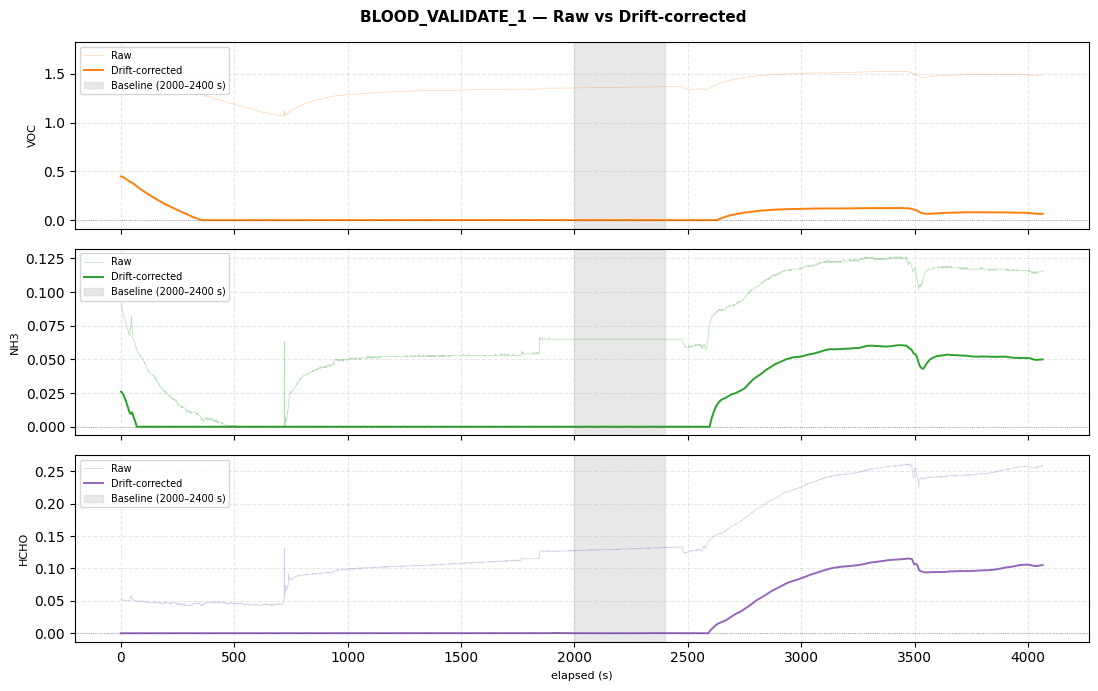

In [203]:
# ── Before / After plot — Raw vs Drift-corrected ──────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)
fig.suptitle("BLOOD_VALIDATE_1 — Raw vs Drift-corrected",
             fontsize=11, fontweight="bold")

for ax, col in zip(axes, MEMS):
    color = COLORS[col]
    t     = blood_val["elapsed_s"]
    ax.plot(t, blood_val[col],           color=color, linewidth=0.5, alpha=0.35, label="Raw")
    ax.plot(t, blood_val_corrected[col], color=color, linewidth=1.4,             label="Drift-corrected")
    ax.axvspan(t0_v, t1_v, color="lightgrey", alpha=0.5, label=f"Baseline ({t0_v}–{t1_v} s)")
    ax.axhline(0, color="black", linewidth=0.6, linestyle=":", alpha=0.4)
    ax.set_ylabel(col.upper(), fontsize=8)
    ax.legend(fontsize=7, loc="upper left")
    ax.grid(True, alpha=0.3, linestyle="--")

axes[-1].set_xlabel("elapsed (s)", fontsize=8)
plt.tight_layout()
plt.show()